In [1]:
import sys
sys.path.append("../../")
from src.rag.schemas.main_state import MainState
from src.rag.prompts.retriever_prompt import (
    RETRIEVER_CONTEXT_SYS,
    ROUTER_QUESTION_TEMPLATE
)
from src.rag.nodes.retriever import retriever_rag
#ports
from src.rag.ports import (
    rag_search,
    llm_port,
    EmbeddingPort
)
#adapters
from src.services import (
    OpenSearchClient,
    create_llm, 
    VectorProcessor
)

from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

In [2]:
chat = create_llm() #default = gpt-4o-mini
opensearch_client = OpenSearchClient()
rag_port = rag_search(opensearch_client)
embedding_converter = EmbeddingPort(VectorProcessor())

2026-03-24 14:13:27 - src.services.llm_factory - INFO - Criando cliente OpenAI com modelo: gpt-4o-mini
2026-03-24 14:13:29 - src.services.opensearch - INFO - Connection with OpenSearch has been achieved. Version: 3.5.0
2026-03-24 14:13:32 - src.services.embedding_processor - INFO - Embed Model successfully loaded. Its dimensions is: 3072


In [3]:
def retriver_node_builder(state: MainState):
    results_from_rag = retriever_rag(
        state=state,
        rag_port=rag_port,
        chat_port=chat,
        k=12,
        min_score=0.6
        )
    return results_from_rag

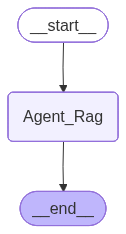

In [4]:
builder = StateGraph(MainState)
builder.add_node("Agent_Rag", retriver_node_builder)

builder.add_edge(START, "Agent_Rag")
builder.add_edge("Agent_Rag", END)

graph_execute = builder.compile()
display(Image(graph_execute.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
prompt = "What are the identified 'atoms of confusion' in code comprehension, and how do they affect developers' understanding according to the study that utilized eye tracking?"
query_vector = embedding_converter.convert_query(prompt)
pdf = "atoms_confusion.pdf"
atoms_pdf = "atoms_confusion.pdf"
index = "content-pdfs"

input_config = {
    "retrieval_rag_input": {
        "index_name": index,
        "query_vector": query_vector,
        "query_text":prompt,
        "book_id": pdf
    }
}

In [6]:
output = graph_execute.invoke(input_config)

2026-03-24 14:13:52 - src.services.opensearch - INFO - 12 chunks found at index 'content-pdfs' | mode: semantic | book_id: 'atoms_confusion.pdf'


In [7]:
output["retrieval_reports"][0]["retrieved_contexts"]

["ABSTRACT\n\nCode comprehension is crucial in software maintenance activities, \nthough it can be hindered by misunderstandings and confusion \npatterns, namely, atoms of confusion. They are small pieces of code \nusing specific programming language constructs, such as Condi- \ntional Operators and Comma Operators. A previous study showed \nthat code comparison was an independent variable to assess coding \ntime and accuracy, and increase code misunderstandings. However, \nempirical knowledge of the impact of such atoms on code compre- \nhension is still scarce, especially when it comes to analyzing that \nimpact on developers' visual attention. The present study evalu- \nates whether developers misunderstand the code in the presence \nof atoms of confusion with an eye tracker. For this purpose, we \nexamined the effect of code on the screen and analyzed them, and \nanalyze the distribution of visual attention. We conducted a \ncontrolled experiment with 30 students and software pract